# Resolution of the VM at LUXE's IP

In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis')

import numpy as _np
import matplotlib.pyplot as _plt
import pybdsim as _bd

initializing ocelot...


### Date and save prefix

In [2]:
date = "2026_06_02"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/ResolutionVM/" + date + "_EuXFEL_plot"

In [3]:
def buildMatrix(rootfile):
    dataPandas = _bd.DataPandas.BDSIMOutput(rootfile)
    quad_names = []
    for name in dataPandas.get_sampler_names():
        if name[0] == 'Q':
            quad_names.append(name)
    X = []
    Y = []
    BPM_list = []
    for quad_name in quad_names:
        BPM_list.append(str(quad_name))
        df = dataPandas.get_sampler(quad_name)
        X.append(df.x.to_numpy())
        Y.append(df.y.to_numpy())
    n = len(df)
    X = _np.array(X).reshape((-1, n))
    Y = _np.array(Y).reshape((-1, n))
    
    df_IP = dataPandas.get_sampler("D2890L.")
    X_IP = _np.array([df_IP.x.to_numpy()])
    Y_IP = _np.array([df_IP.y.to_numpy()])
    
    return _np.concatenate((X, Y), axis=0), X_IP, Y_IP

def calcCoeffsWithSVD(M, ref_Vect):
    U, d, V_t = _np.linalg.svd(M, full_matrices=False)
    D = _np.diag(d)

    D_i = _np.linalg.inv(D)
    U_t = U.transpose()
    V = V_t.transpose()

    C = _np.dot(ref_Vect, _np.dot(V, _np.dot(D_i, U_t)))
    return C

def calcMeasuredPositionAndNResidual(M, ref_Vect):
    C = calcCoeffsWithSVD(M, ref_Vect)
    meas_Vect = _np.dot(C, M)
    Residual = ref_Vect - _np.dot(C, M)

    return meas_Vect, Residual.flatten()

def SortBPMperCoeff(M, ref_Vect):
    C_vect = calcCoeffsWithSVD(M, ref_Vect).flatten()
    order = _np.argsort(_np.abs(C_vect))[::-1]
    return M[order,:], C_vect[order]

In [4]:
bdsim_in = "../../luxe-elbex/manchester_farm/background/gmad_files/XTD8_no_DBA_match_no_R56.gmad"
bdsim_out = "jupyter_notebooks/XTD8_no_DBA_match_no_R56_tracking"

In [5]:
_bd.Run.Bdsim(bdsim_in, bdsim_out, ngenerate=50000, seed=0, silent=True)

0

In [6]:
M_track, X_IP, Y_IP = buildMatrix(bdsim_out+'.root')

In [60]:
M_noise = _np.random.normal(0, 3e-6, M_track.shape)
M_meas = M_track + M_noise
X_IP_noise = _np.random.normal(0, 1.39e-6, X_IP.shape)
X_IP_meas = X_IP + X_IP_noise
Y_IP_noise = _np.random.normal(0, 4.09e-6, Y_IP.shape)
Y_IP_meas = Y_IP + Y_IP_noise

In [61]:
meas_Vect_X, RX = calcMeasuredPositionAndNResidual(M_meas, X_IP_meas)
meas_Vect_Y, RY = calcMeasuredPositionAndNResidual(M_meas, Y_IP_meas)

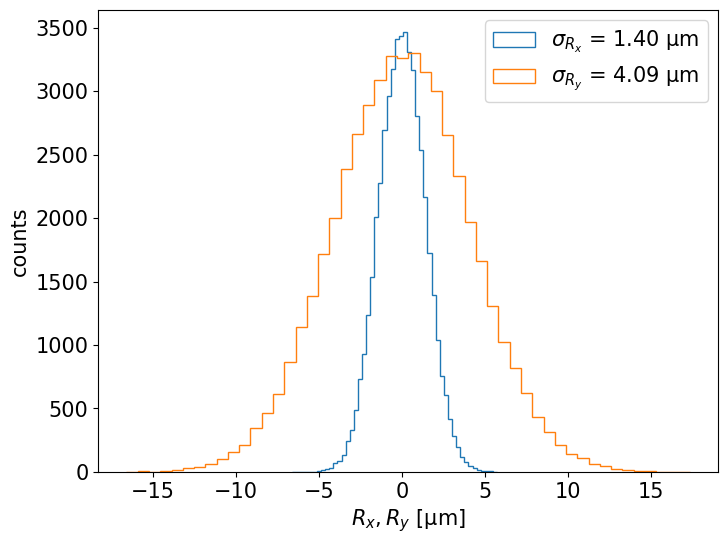

In [62]:
_plt.rcParams['font.size'] = 15
_plt.figure(figsize=[8,6])
_plt.hist(RX*1e6, histtype='step', bins=50, label=r"$\sigma_{{R_x}}$ = {:.2f} $\rm \mu m$".format(_np.std(RX*1e6)))
_plt.hist(RY*1e6, histtype='step', bins=50, label=r"$\sigma_{{R_y}}$ = {:.2f} $\rm \mu m$".format(_np.std(RY*1e6)))
_plt.ylabel("counts")
_plt.xlabel(r"$R_x, R_y$ [$\rm \mu$m]")
_plt.legend()
_plt.savefig("{}_Resolution_XY.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

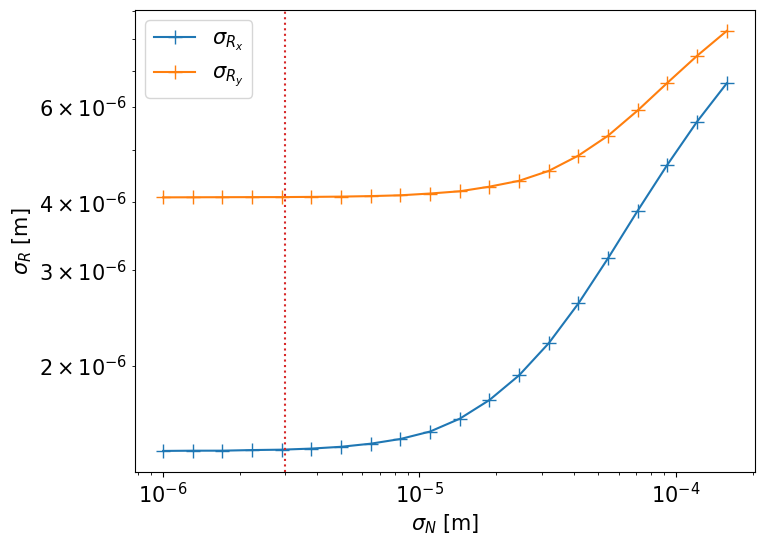

In [63]:
noise_range = _np.logspace(-6, -3.8, 20)
std_RX = []
std_RY = []
for noise in noise_range:
    M_noise = _np.random.normal(0, noise, M_track.shape)
    M = M_track + M_noise
    meas_Vect_X, RX = calcMeasuredPositionAndNResidual(M, X_IP_meas)
    meas_Vect_Y, RY = calcMeasuredPositionAndNResidual(M, Y_IP_meas)
    std_RX.append(_np.std(RX))
    std_RY.append(_np.std(RY))
_plt.figure(figsize=[8,6])
_plt.plot(noise_range, std_RX, '+-', markersize=10, markeredgewidth=1, label=r"$\sigma_{R_x}$")
_plt.plot(noise_range, std_RY, '+-', markersize=10, markeredgewidth=1, label=r"$\sigma_{R_y}$")
_plt.ylabel(r"$\sigma_R$ [m]")
_plt.xlabel(r"$\sigma_N$ [m]")
# _plt.ylim([1e-6, 2e-5])
_plt.axvline(3e-6, ls=':', color='C3')
_plt.legend()
_plt.semilogx()
_plt.semilogy()
_plt.savefig("{}_Resolution_per_noise_XY.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

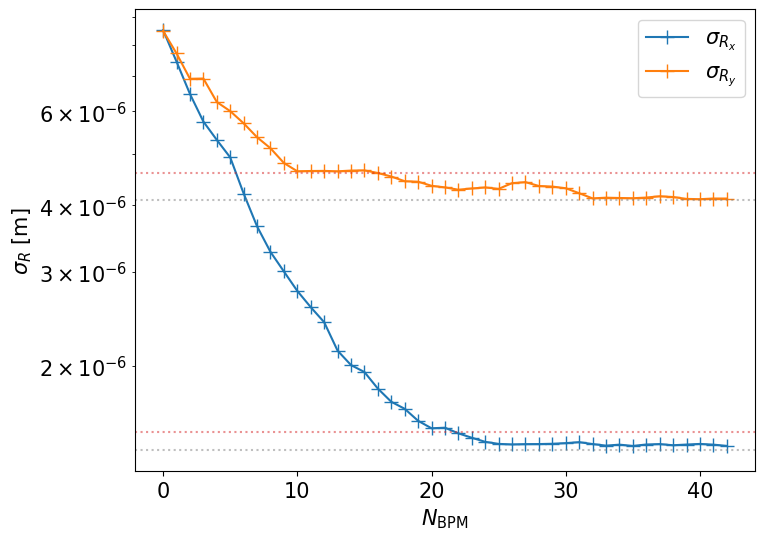

In [68]:
BPM_ID = range(43)
std_RX = []
std_RY = []
MX, CX = SortBPMperCoeff(M_meas, X_IP_meas)
MY, CY = SortBPMperCoeff(M_meas, Y_IP_meas)
for i in BPM_ID:
    RX = X_IP_meas - _np.dot(CX[:i+1], MX[:i+1,:])
    RY = Y_IP_meas - _np.dot(CY[:i+1], MY[:i+1,:])
    std_RX.append(_np.std(RX))
    std_RY.append(_np.std(RY))
_plt.figure(figsize=[8,6])
_plt.plot(BPM_ID, std_RX, '+-', markersize=10, markeredgewidth=1, label=r"$\sigma_{R_x}$")
_plt.plot(BPM_ID, std_RY, '+-', markersize=10, markeredgewidth=1, label=r"$\sigma_{R_y}$")
_plt.ylabel(r"$\sigma_R$ [m]")
_plt.xlabel(r"$N_{\rm BPM}$")
_plt.axhline(1.5e-6, ls=':', color='C3', alpha=0.5)
_plt.axhline(4.6e-6, ls=':', color='C3', alpha=0.5)
_plt.axhline(1.39e-6, ls=':', color='gray', alpha=0.5)
_plt.axhline(4.09e-6, ls=':', color='gray', alpha=0.5)
_plt.legend()
_plt.semilogy()
_plt.savefig("{}_Resolution_per_BPM_XY.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [85]:
P_L = 350e12
w_0 = 5e-6
c = 3e8
e_0 = 8.854e-12
E_cr = 1.32e18
gamma = 1e4
theta = 0

I_0 = 2*P_L/(_np.pi*w_0**2)
E_0 = _np.sqrt(2*I_0/(c*e_0))
E_star = gamma*E_0 * (1 + _np.cos(theta))

In [86]:
E_star/E_cr

np.float64(1.2412085411280196)